# Customer Churn Analysis

## Business Problem

Customer churn occurs when customers stop using a company's products or services. High churn rates can lead to significant revenue loss and reduced business growth.

This project analyzes customer data to identify factors contributing to customer attrition and provides insights that can help improve customer retention.

# Dataset Overview

### Objective

Understand the structure of the dataset, identify available features, and inspect data quality before performing analysis.

### Dataset Information

The dataset contains customer demographic information, account details, banking behavior, and churn status.

Target Variable:

- Exited = 1 → Customer Left
- Exited = 0 → Customer Stayed

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Churn_Modelling.csv",low_memory=False)
print(df.shape)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


# Data Cleaning

### Objective

Prepare the dataset for analysis by identifying missing values, duplicate records, and unnecessary columns.

### Tasks Performed

- Checked for missing values
- Checked for duplicate records
- Removed irrelevant columns
- Verified data types

In [9]:
print(df.isnull().sum())


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [10]:
print(df.duplicated().sum())

0


In [17]:
df=df.drop(
    columns=["RowNumber","CustomerId","Surname"]
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Customer Churn Overview

### Objective

Analyze the overall churn distribution and determine the proportion of customers who left the bank.

### Business Importance

Understanding churn rates helps organizations evaluate customer retention performance and estimate potential revenue loss.

Exited
0    7963
1    2037
Name: count, dtype: int64


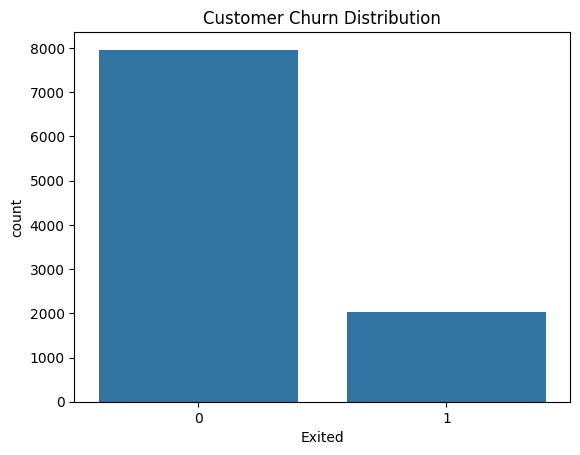

In [25]:
churn_counts=df["Exited"].value_counts()
print(churn_counts)
sns.countplot(
    x="Exited",
    data=df
)
plt.title("Customer Churn Distribution")")
plt.show()

# Gender vs Churn Analysis

### Objective

Examine whether customer churn varies across different gender groups.

### Business Importance

Identifying gender-specific churn trends can help businesses create targeted customer retention strategies.

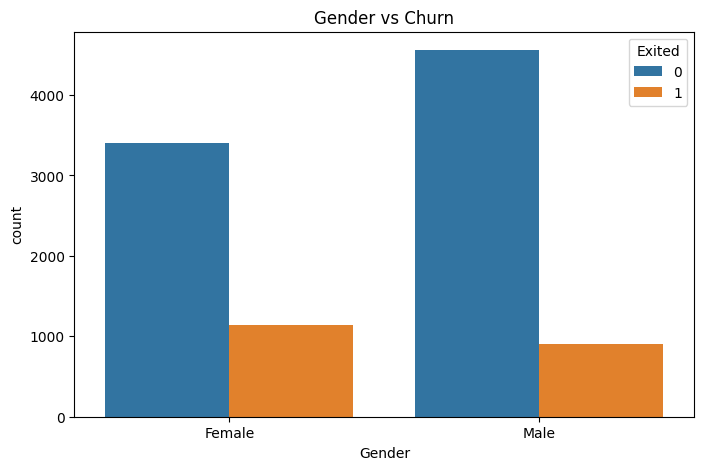

In [28]:

plt.figure(figsize=(8,5))

sns.countplot(
    x="Gender",
    hue="Exited",
    data=df
)

plt.title("Gender vs Churn")

plt.show()

# Geography Analysis

### Objective

Analyze customer churn across different geographic regions.

### Business Importance

Regional churn differences may indicate varying customer satisfaction levels, market conditions, or competitive pressures.

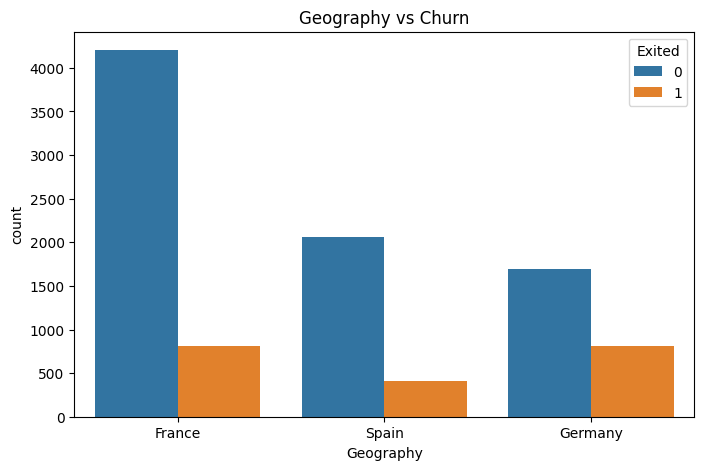

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

plt.title("Geography vs Churn")

plt.show()

# Age Distribution Analysis

### Objective

Understand the age profile of customers within the dataset.

### Business Importance

Age demographics provide valuable insights into customer segments and their behavior patterns.

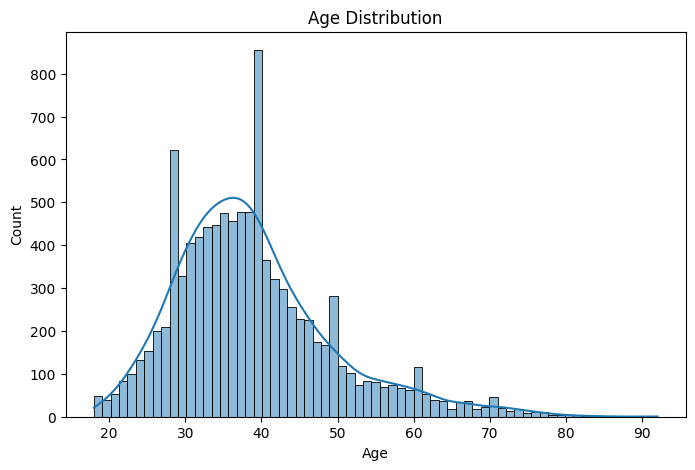

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    kde=True
)

plt.title("Age Distribution")

plt.show()

# Age vs Churn Analysis

### Objective

Investigate whether customer age influences churn behavior.

### Business Importance

Understanding age-related churn trends helps organizations focus retention efforts on high-risk age groups.

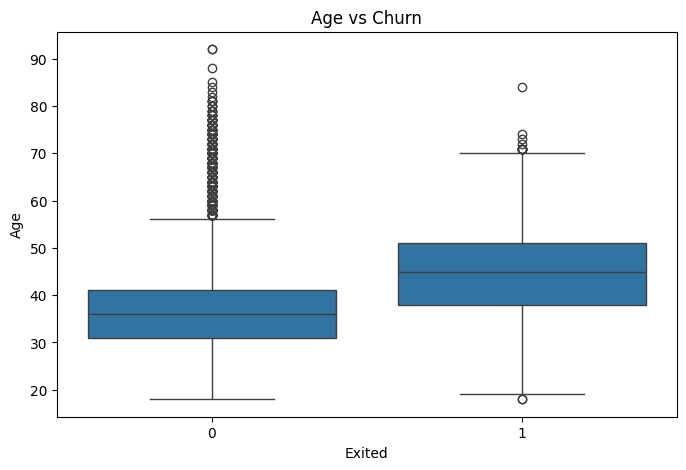

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

plt.title("Age vs Churn")

plt.show()

# Account Balance Analysis

### Objective

Analyze the relationship between customer account balances and churn behavior.

### Business Importance

Balance levels may indicate customer engagement and financial value to the business.

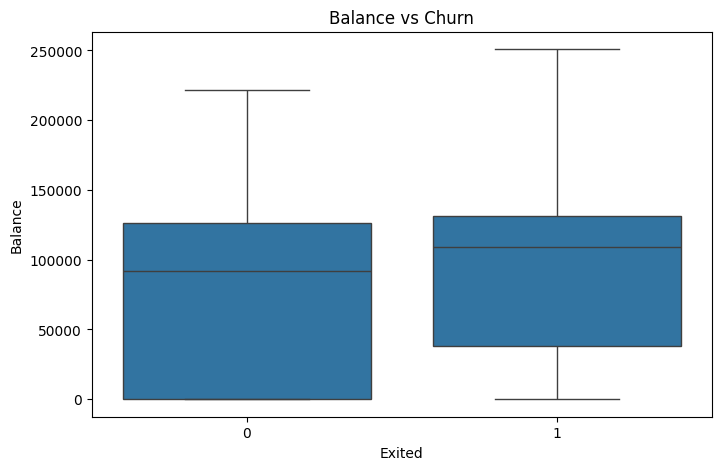

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.title("Balance vs Churn")

plt.show()

# Active Member Analysis

### Objective

Compare churn behavior between active and inactive customers.

### Business Importance

Customer engagement is often a key indicator of long-term retention and customer loyalty.

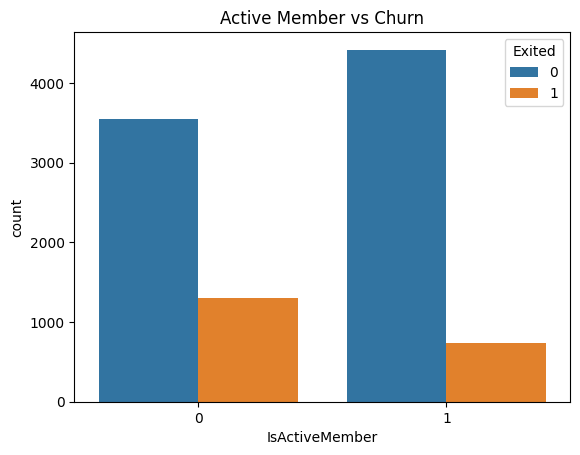

In [43]:
sns.countplot(
    x="IsActiveMember",
    hue="Exited",
    data=df
)

plt.title("Active Member vs Churn")

plt.show()

# Credit Card Analysis

### Objective

Analyze whether credit card ownership influences customer churn.

### Business Importance

Additional banking products may increase customer retention and strengthen customer relationships.

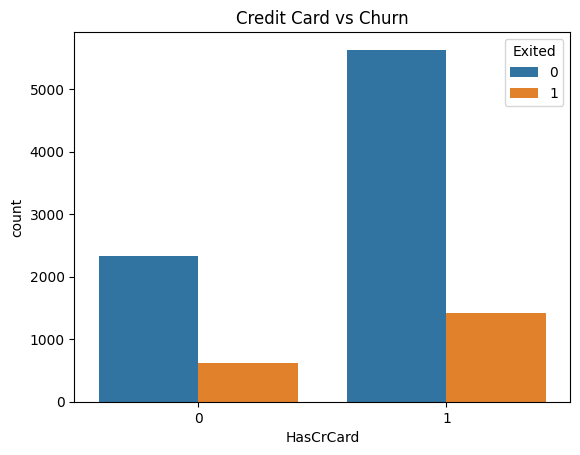

In [44]:
sns.countplot(
    x="HasCrCard",
    hue="Exited",
    data=df
)

plt.title("Credit Card vs Churn")

plt.show()

# Correlation Analysis

### Objective

Identify relationships between numerical variables in the dataset.

### Business Importance

Correlation analysis helps uncover important factors that may influence customer churn.

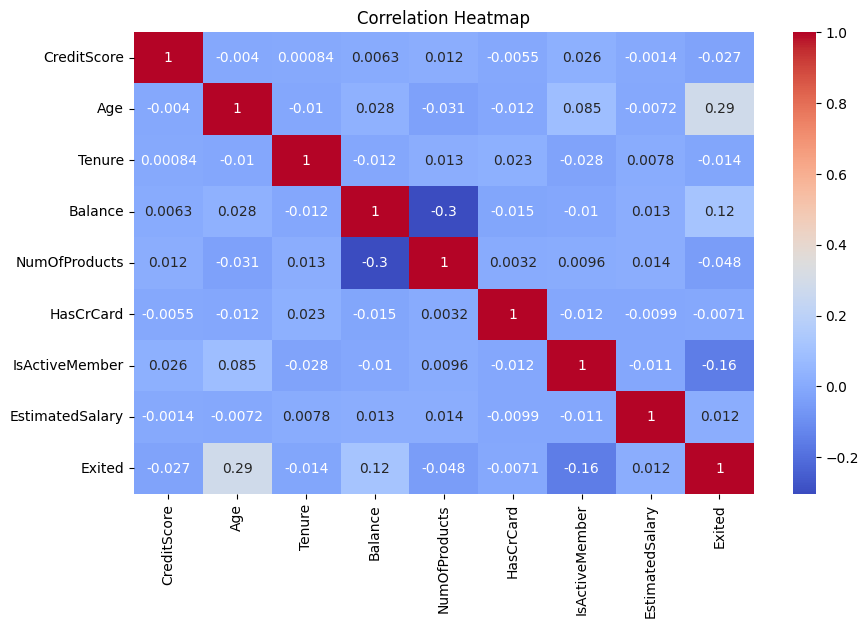

In [48]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Churn Rate Analysis

### Objective

Calculate the percentage of customers who exited the bank.

### Business Importance

The churn rate is one of the most important metrics used to measure customer retention performance.

In [46]:
churn_rate = (
    df["Exited"].sum() /
    len(df)
) * 100

print(
    f"Churn Rate: {churn_rate:.2f}%"
)

Churn Rate: 20.37%


# Executive Summary

### Key Findings

- Customer churn remains a significant business challenge.
- Churn behavior varies across customer demographics.
- Customer activity levels influence retention.
- Geographic factors contribute to churn differences.
- Customer engagement appears to reduce churn risk.

### Recommendations

- Focus retention efforts on high-risk customer groups.
- Improve customer engagement programs.
- Monitor regional churn trends.
- Develop targeted loyalty initiatives.
- Strengthen customer relationship strategies.

# Conclusion

This Customer Churn Analysis project examined customer demographics, account information, and banking behavior to understand factors influencing customer attrition.

The analysis revealed that customer churn varies across age groups, geographic regions, account balances, and customer activity levels. Active customers tend to remain with the bank, while certain customer segments show a higher likelihood of leaving.

By identifying key churn patterns, businesses can develop targeted retention strategies, improve customer engagement, and reduce revenue loss caused by customer attrition.

Overall, this analysis provides valuable insights that can support data-driven decision-making and help improve long-term customer retention.